<a href="https://colab.research.google.com/github/NatalieAleksandrova2026/ShopSphere_ua/blob/main/python_project/coffee_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ☕ Прогнозування продажів кав'ярні (Forecast)

## Завдання з машинного навчання для початківців

У цьому проєкті ви навчите просту модель, яка **прогнозує майбутні продажі** на основі минулих даних. Ми використаємо `scikit-learn` — найпопулярнішу бібліотеку машинного навчання в Python.

**Не хвилюйтесь, якщо мало досвіду з Python** — більшість коду вже написана. Ваше завдання:
1. Запускати клітинки по черзі (Shift + Enter)
2. Заповнити кілька пропусків, позначених `# ⬅️ ВАШ КОД`
3. **Головне — інтерпретувати результати** (відповіді пишіть у клітинках з питаннями)

---

### Легенда
Ви — аналітик мережі кав'ярень **"CoffeeTime"**. У вас є дані про щомісячну виручку за 3 роки (2022–2024). Директор хоче знати: **скільки ми зароблятимемо в наступні місяці?** Побудуйте прогноз і поясніть його простими словами.

## Крок 1. Підключаємо бібліотеки

Спочатку завантажимо потрібні інструменти. Просто запустіть цю клітинку — тут нічого міняти не треба.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

print("Libraries connected! ✅")

Libraries connected! ✅


## Крок 2. Завантажуємо дані

Прочитаємо файл `coffee_sales.csv` і подивимось на перші рядки.

In [ ]:
df = pd.read_csv("coffee_sales.csv")

# Let's inspect the first 5 rows
df.head()

,month_number,year,month,month_name,revenue
0,1,2022,1,Січень,12499
1,2,2022,2,Лютий,11712
2,3,2022,3,Березень,14006
3,4,2022,4,Квітень,15618
4,5,2022,5,Травень,14688


**Що означають стовпці:**
- `month_number` — порядковий номер місяця (1, 2, 3 ... 36). Це наш **головний вхідний параметр** (X)
- `year`, `month`, `month_name` — рік, номер і назва місяця (для зручності)
- `revenue` — виручка за місяць у гривнях. Це те, що ми **прогнозуємо** (y)

In [4]:
# How much data do we have?
print(f"Number of months in data: {len(df)}")
print(f"First month: {df['revenue'].iloc[0]} UAH")
print(f"Last month: {df['revenue'].iloc[-1]} UAH")

Number of months in data: 36
First month: 12499 UAH
Last month: 30642 UAH


## Крок 3. Дивимось на дані очима

Перш ніж щось прогнозувати, аналітик **завжди спочатку дивиться на графік**. Побудуємо графік виручки за всі 36 місяців.

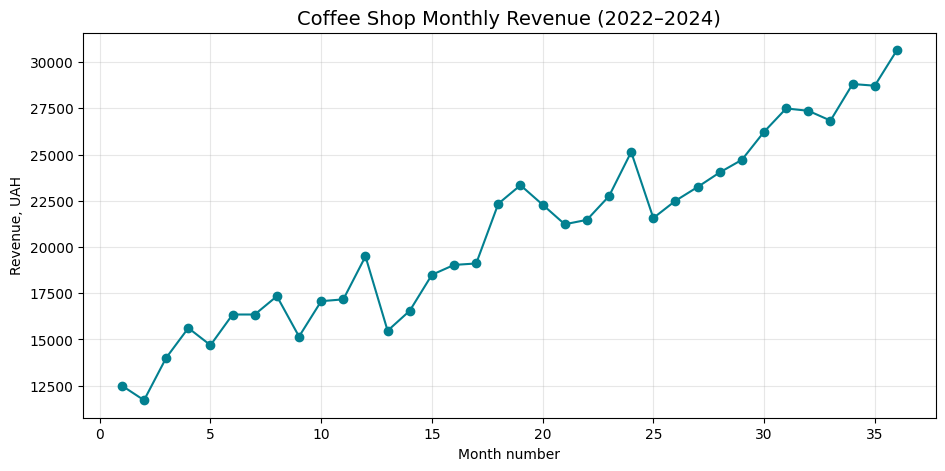

In [5]:
plt.figure(figsize=(11, 5))
plt.plot(df["month_number"], df["revenue"], marker="o", color="#028090")
plt.title("Coffee Shop Monthly Revenue (2022–2024)", fontsize=14)
plt.xlabel("Month number")
plt.ylabel("Revenue, UAH")
plt.grid(alpha=0.3)
plt.show()

### ❓ Питання 1 (інтерпретація)

Подивіться на графік уважно і дайте відповідь текстом:

1. Який **загальний напрямок** руху виручки? (зростає / падає / стоїть на місці)
2. Чи бачите ви якісь **регулярні коливання** (наприклад, сезонні піки влітку чи взимку)?
3. Як гадаєте, чи можна за таким графіком приблизно вгадати, що буде далі?

**Ваша відповідь:**

## Answer — Question 1: Reading the Graph

**1. Overall direction:**
Revenue is clearly **increasing** over the 36-month period. It starts around 12,500 UAH in month 1 and ends around 30,600 UAH in month 36 — roughly a 2.4x increase over three years. The growth is not perfectly smooth, but the long-term trend is unmistakably upward.

**2. Regular fluctuations:**
Yes, there are noticeable ups and downs layered on top of the trend. The line does not move in a straight diagonal — it zig-zags, with local dips (e.g. around months 2, 9, 13, 21, 25) followed by recoveries, and occasional sharp spikes (e.g. month 12 and especially month 24, which jumps well above the surrounding months before dropping back down). These could reflect seasonal patterns (e.g. holiday or summer/winter effects) or one-off events, but with only 3 years of data it's hard to confirm a repeating yearly cycle with confidence — this would require checking whether the same calendar months spike each year.

**3. Predictability:**
Because there is a fairly consistent upward trend, it is reasonable to expect revenue will **continue growing** in the near future, at least roughly. However, predicting the *exact* value for any given month is much harder due to the visible noise/volatility around the trend — actual values can swing a few thousand UAH above or below what a simple trend line would suggest. So a forecast can give a believable general direction and order of magnitude, but not a precise number with high confidence.

...


## Крок 4. Готуємо дані для моделі

Модель навчається на парах «вхід → вихід». У нас:
- **Вхід (X)** — номер місяця (`month_number`)
- **Вихід (y)** — виручка (`revenue`)

Модель шукатиме залежність: «як виручка залежить від номера місяця».

In [7]:
# X — вхідні дані (features). Подвійні дужки [[ ]] потрібні, щоб отримати таблицю, а не список
X = df[["month_number"]]

# y — те, що прогнозуємо (target)
y = df["revenue"]

print("X (First 3):")
print(X.head(3))
print("\ny (First 3):")
print(y.head(3))

X (First 3):
   month_number
0             1
1             2
2             3

y (First 3):
0    12499
1    11712
2    14006
Name: revenue, dtype: int64


## Крок 5. Навчаємо модель

Тепер найголовніше — навчання. Ми використаємо **лінійну регресію** — найпростішу модель, яка проводить пряму лінію крізь наші точки.

Модель за нас знайде два числа:
- **нахил (slope)** — на скільки гривень зростає виручка щомісяця
- **перетин (intercept)** — з якого рівня все починалось

Заповніть один пропуск нижче: викличте `.fit(X, y)`, щоб навчити модель.

In [8]:
# Створюємо модель
model = LinearRegression()

# Навчаємо модель на наших даних
model.fit(X, y)      # ⬅️ ВАШ КОД: тут ми "показуємо" моделі дані X та y

print("Model trained! ✅")
print(f"Slope: {model.coef_[0]:.0f} UAH per month")
print(f"Intercept: {model.intercept_:.0f} UAH")

Model trained! ✅
Slope: 459 UAH per month
Intercept: 12247 UAH


### ❓ Питання 2 (інтерпретація)

Модель порахувала **нахил (slope)**. Це найважливіше число прогнозу.

1. Чому дорівнює нахил? Що він означає **простими словами** для директора кав'ярні?
   (Підказка: «Щомісяця виручка в середньому зростає на ___ грн»)
2. Перетин (intercept) — це теоретична виручка в «місяць 0». Чи має він реальний бізнес-сенс тут?

**Ваша відповідь:**
## Answer — Question 2: Meaning of the Slope

**1. Slope (459 UAH per month):**
The slope tells us how much revenue changes, on average, from one month to the next. In plain terms for the director: **"Every month, the coffee shop's revenue grows by about 459 UAH on average, compared to the previous month."** Over a year, that's roughly 459 × 12 ≈ 5,500 UAH of average growth — which matches the strong upward trend we saw in the graph. This is the single most useful number for budgeting, since it summarizes the overall growth rate in one figure.

**2. Intercept (12,247 UAH):**
The intercept is the model's predicted revenue at month 0 — i.e., one month *before* the data even starts. Mathematically it's just where the line crosses the y-axis, and it happens to be reasonably close to the actual month-1 revenue (~12,500 UAH), so in this case it roughly lines up with reality. However, it doesn't have a true independent business meaning on its own — "month 0" isn't a real point in time, and the intercept is really just a mathematical anchor point for the line, not a business milestone. It shouldn't be interpreted as "revenue before the shop opened" or anything like that — it's a byproduct of the fitting process, not a business insight.
...


## Крок 6. Перевіряємо, як модель описує минуле

Спочатку подивимось, наскільки добре пряма лінія моделі лягає на реальні дані. Побудуємо графік: реальні точки + лінія прогнозу.

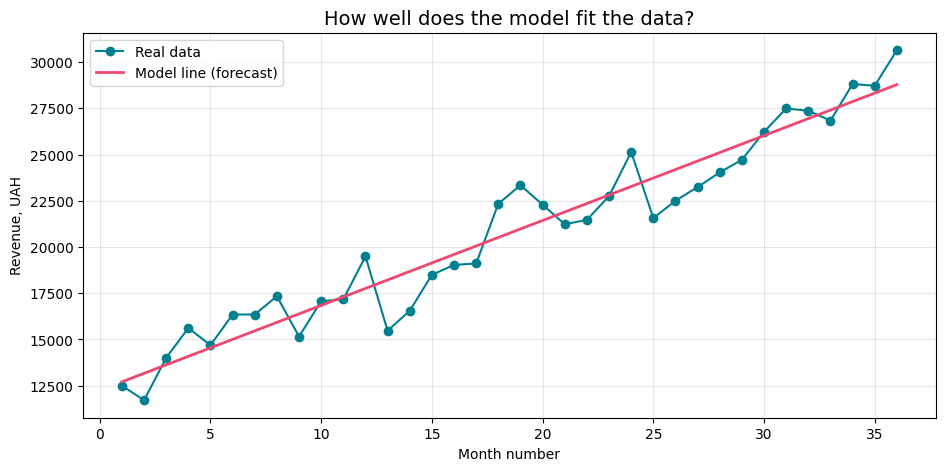

In [10]:
# Прогноз моделі для всіх наявних місяців
df["predicted"] = model.predict(X)

plt.figure(figsize=(11, 5))
plt.plot(df["month_number"], df["revenue"], marker="o", color="#028090", label="Real data")
plt.plot(df["month_number"], df["predicted"], color="#EF476F", linewidth=2, label="Model line (forecast)")
plt.title("How well does the model fit the data?", fontsize=14)
plt.xlabel("Month number")
plt.ylabel("Revenue, UAH")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### ❓ Питання 3 (інтерпретація)

1. Наскільки добре червона лінія «ловить» загальний тренд синіх точок?
2. Точки не лежать ідеально на лінії — вони то вище, то нижче. **Чому**, на вашу думку? (згадайте про сезонність)
3. Чи вважаєте ви, що проста пряма лінія — це достатньо добре для директора, чи потрібна складніша модель?

**Ваша відповідь:**
## Answer — Question 3: Does the Line Fit Well?

**1. How well does the line capture the overall trend?**
The red line does a good job of capturing the **overall long-term trend** — it clearly shows revenue rising steadily from about 12,500 UAH to about 28,600 UAH over the 36 months, which matches the general shape of the data. As a summary of "which direction is the business heading," the line is quite accurate.

**2. Why don't the points sit exactly on the line?**
The points bounce above and below the line because a straight line only captures the *average* linear growth — it cannot capture short-term fluctuations. These deviations likely come from a mix of factors:
- **Seasonality** — certain months may consistently see more or less coffee shop traffic (e.g. summer vs. winter, holidays, back-to-school season), causing repeating peaks and dips that a straight line can't represent since it only moves in one constant direction.
- **Random/one-off events** — things like weather, local promotions, one-time events, or noise in the data (e.g. the sharp spike at month 24, or the dip at month 25) that don't repeat in a predictable pattern.
- **Real-world variability** — revenue rarely grows in perfectly equal increments; a linear model smooths all of this into one straight average.

**3. Is a straight line good enough, or is a more complex model needed?**
A straight line is **good enough for a rough, high-level estimate** of the general growth trend and for long-term budget planning — it's simple, easy to explain, and captures the main direction correctly. However, it is **not good enough for precise month-to-month forecasting**, especially if the director wants to know things like "how much extra revenue can we expect in December" or "should we staff up in summer." For that, a more complex model — one that accounts for seasonality (e.g. seasonal decomposition, or models like SARIMA, or adding month/season as a feature) — would be more useful and accurate. In short: the simple line is a solid starting point, but it should be presented with the caveat that it smooths over meaningful patterns the director might care about.
...


## Крок 7. 🔮 Прогноз на майбутнє

А тепер — головне, заради чого все робилось. Спрогнозуємо виручку на **наступні 6 місяців** (місяці 37–42, тобто перша половина 2025 року).

Заповніть пропуск: створіть список майбутніх номерів місяців від 37 до 42.

In [11]:
# Майбутні місяці: 37, 38, 39, 40, 41, 42
future_months = pd.DataFrame({"month_number": [37, 38, 39, 40, 41, 42]})   # ⬅️ ВАШ КОД

# Прогнозуємо виручку для них
future_predictions = model.predict(future_months)

# Показуємо результат
for m, pred in zip(future_months["month_number"], future_predictions):
    print(f"Month {m}: forecast ≈ {pred:.0f} UAH")

Month 37: forecast ≈ 29242 UAH
Month 38: forecast ≈ 29701 UAH
Month 39: forecast ≈ 30161 UAH
Month 40: forecast ≈ 30620 UAH
Month 41: forecast ≈ 31079 UAH
Month 42: forecast ≈ 31539 UAH


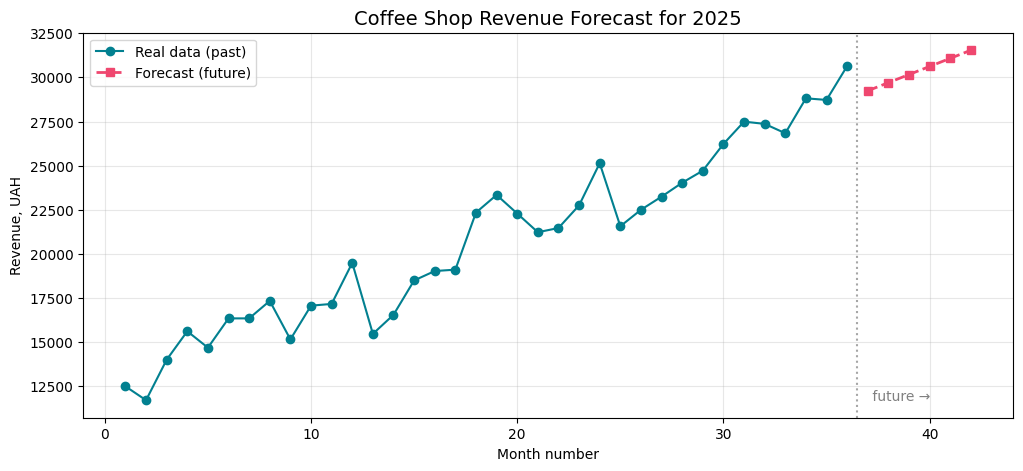

In [12]:
# Побудуємо фінальний графік: минуле + прогноз
plt.figure(figsize=(12, 5))

# Реальні дані
plt.plot(df["month_number"], df["revenue"], marker="o", color="#028090", label="Real data (past)")

# Прогноз на майбутнє
plt.plot(future_months["month_number"], future_predictions,
         marker="s", color="#EF476F", linewidth=2, linestyle="--", label="Forecast (future)")

plt.axvline(x=36.5, color="gray", linestyle=":", alpha=0.7)
plt.text(37, df["revenue"].min(), " future →", color="gray")
plt.title("Coffee Shop Revenue Forecast for 2025", fontsize=14)
plt.xlabel("Month number")
plt.ylabel("Revenue, UAH")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### ❓ Питання 4 (інтерпретація — найважливіше!)

1. Яку виручку модель прогнозує на **місяць 42** (червень 2025)?
2. Директор питає: «**Чи можна повністю довіряти цьому прогнозу?**» Що ви відповісте? Назвіть хоча б **дві причини**, чому реальність може відрізнятись від прогнозу.
3. Наша модель малює **пряму лінію** — вона припускає, що зростання триватиме вічно тим самим темпом. У яких ситуаціях це припущення може бути **небезпечним** для бізнесу?

**Ваша відповідь:**
## Answer — Question 4: Can We Trust This Forecast? (Most Important)

**1. Forecast for month 42 (June 2025):**
The model predicts revenue of approximately **31,539 UAH** for month 42.

**2. Can we fully trust this forecast?**
No — this forecast should be treated as a **rough estimate, not a guarantee**. I would tell the director: "This gives us a reasonable ballpark for planning, but it shouldn't be treated as a precise number." At least two reasons reality could differ:

- **The model ignores seasonality and short-term fluctuations.** We already saw the real data zig-zag noticeably around the trend line (e.g. the spike at month 24, the dip at month 25) — swings of a few thousand UAH are common. The forecast line is perfectly smooth, but real months rarely are.
- **The model assumes the future behaves like the past.** It has no awareness of things that could change the business — a new competitor opening nearby, an economic downturn or inflation spike, a change in coffee prices, a marketing campaign, or even one-off disruptions (weather, supply issues, etc.). Linear regression simply extrapolates the historical average trend; it can't anticipate structural changes.

**3. Why is assuming growth continues "forever" dangerous?**
A straight line assumes the **same constant absolute growth (459 UAH/month) continues indefinitely, with no limit**. This is dangerous in several real business situations:

- **Markets saturate.** A coffee shop can't grow revenue forever at the same pace — eventually it runs out of new customers, physical capacity (seats, staff, working hours), or local demand plateaus. Real growth curves usually flatten out (more like an S-curve) rather than continuing as a straight line forever.
- **Extrapolating too far into the future compounds error.** The farther out you forecast, the more small assumption errors accumulate, and the model can predict unrealistic numbers.
- **It ignores downturns and shocks.** A recession, rent increase, health crisis, or new competition could hit revenue, but the model would keep predicting steady growth regardless — giving false confidence to budget decisions.
- **Practical business risk:** if the director budgets expenses (hiring, rent, expansion) based on the assumption that revenue will keep climbing at exactly this rate, and reality falls short, the business could overextend itself financially.

**Bottom line for the director:** use this forecast as a **directional guide for short-term planning** (next few months), not as a precise number to bet the budget on — and revisit/retrain the model regularly as new real data comes in.
...


## Крок 8. ⭐ Бонусне завдання (необов'язкове)

Спробуйте спрогнозувати виручку на **один конкретний місяць** — наприклад, місяць 50 (лютий 2026).

Підказка: скопіюйте логіку з Кроку 7, але передайте лише одне число.

In [13]:
# Ваш експеримент тут:
one_month = pd.DataFrame({"month_number": [50]})
prediction = model.predict(one_month)
print(f"Forecast for month 50: {prediction[0]:.0f} UAH")

# ❓ Питання-бонус: чим ДАЛІ в майбутнє ми прогнозуємо, тим прогноз...
#    (надійніший чи менш надійний?) Чому? Напишіть відповідь коментарем нижче:
# Відповідь: ...

Forecast for month 50: 35213 UAH


Answer:

The further into the future we forecast, the LESS reliable the forecast becomes.

Why:
1. The model only "knows" the pattern from the 36 months it was trained on. Month 42 is just 6 months past the last real data point — a small extrapolation. Month 50 is 14 months past the data — more than a full year beyond anything the model has ever seen.
2. A linear model assumes the exact same trend (459 UAH/month) continues forever, with zero allowance for the business to slow down, plateau, or be hit by a shock. The longer the horizon, the more time there is for real-world conditions (competition, economy, demand limits) to diverge from that assumption, and small errors in the slope/intercept get multiplied over more months.
3. There is no real data to check the forecast against that far out — we are purely trusting the straight line, with no way to verify it.

In short: near-term forecasts (a few months ahead) are reasonably usable for planning, but far-future forecasts (a year or more ahead) should be treated with much more caution, since the model has no way to know if the business's growth pattern will still look the same by then.

## 🎓 Підсумок

Вітаємо! Ви щойно:
- ✅ Завантажили й дослідили реальні дані
- ✅ Навчили модель машинного навчання (лінійну регресію)
- ✅ Зробили прогноз на майбутнє
- ✅ **Найголовніше — навчились інтерпретувати результати й розуміти обмеження моделі**

### Що здати
Збережіть цей ноутбук з **усіма відповідями** на питання 1–4 (і бонус) та надішліть викладачу.

### Головний урок
Модель — це лише інструмент. Її прогноз рівно настільки хороший, наскільки хороші дані й наскільки розумно ви інтерпретуєте результат. **Аналітик, який розуміє обмеження моделі, цінніший за того, хто просто вміє натиснути `.fit()`.**